## The question we want to answer

A bead in water is pulled toward a resting position while surrounding molecules give it random kicks. Release it repeatedly from the same point: each run draws a different curve. Can we identify a path with the highest density, and why should that path obey the noiseless equation of motion?

This chapter builds Equation (4) of Friston et al. (2023) from probability, then explains each of its three lines:

$$
\begin{aligned}
\mathbf{x}[\tau]&=\underset{x[\tau]}{\arg\min}\,\mathcal A(x[\tau])\\
&\Leftrightarrow\delta_x\mathcal A(\mathbf{x}[\tau])=0\\
&\Leftrightarrow\dot{\mathbf{x}}(\tau)=f(\mathbf{x}).
\end{aligned}
\tag{4}
$$

The bold type denotes the selected most likely path, not simply a vector. Here $x$ may itself be a vector.

**Prerequisites:** derivatives, Gaussian densities, integration, and matrix multiplication. We introduce functionals and variations as we need them. The numerical sections use NumPy, SciPy, and Matplotlib; all plots are saved inside this notebook after execution. You can read the derivation without running Python.

**Our working assumptions:** additive noise with constant symmetric positive-definite $\Gamma$; fixed initial state $x(0)=x_0$; free terminal state; sufficiently regular drift with a unique deterministic solution over $[0,\tau]$. For the central proof, we omit the divergence term exactly as the paper's footnote 4 does. We will explain that qualification rather than silently extending the result to every stochastic system.

The learning route is: **step probabilities → path surprisal → quadratic action → its minimum → vanishing variation → deterministic flow.**

## 1. A snapshot is different from a movie

The paper starts with the formal Langevin equation

$$\dot x(t)=f(x(t))+\omega(t).$$

Here $f$ is the systematic drift and $\omega$ represents rapidly fluctuating noise. For our spring-like example, $f(x)=-kx$, with $k>0$.

| Symbol | Meaning | Bead example |
|---|---|---|
| $x(t)$ | State at one time | One photograph of its position |
| $x[\tau]=\{x(t):0\leq t\leq\tau\}$ | Whole trajectory | The complete movie |
| $p(x,\tau)$ | State density | Where it may be at time $\tau$ |
| $p(x[\tau]\mid x_0)$ | Formal path density given its start | Which movie may unfold |

The Fokker–Planck equation, Equation (2), evolves the state density. Equation (3) describes paths through their action. Equation (4) selects a path from that description. Equation (5) names the negative log state density *surprisal* and relates average surprisal and action to entropies.

In continuous spaces, an exact state or exact path normally has probability zero. A density describes relative likelihood with respect to a specified measure. We first use a finite time grid, where the density over $(x_1,\ldots,x_N)$ is unambiguous.

## 2. Surprisal is the right currency

For a discrete event $E$, define

$$\mathfrak I(E)=-\ln p(E).$$

An event of probability $1$ has zero surprisal; an event of probability $0.01$ has surprisal about $4.605$ nats. The natural logarithm gives the unit *nat*. Rare events receive larger scores.

The crucial property is

$$-\ln(ab)=-\ln a-\ln b.$$

For independent events, probabilities multiply and surprisals add. For dependent events we instead use conditional probabilities:

$$-\ln p(A,B)=-\ln p(A)-\ln p(B\mid A).$$

This conditional version is what a trajectory needs. **Successive positions are not independent.** Their dependence is retained by conditioning each step on the previous position.

The paper defines action by applying the same transformation to a whole path:

$$\mathcal A(x[\tau])\equiv-\ln p(x[\tau]\mid x_0).$$

Thus “action is path surprisal” is a definition. The work is to show why it has the integral structure of an action.

A negative log density need not be positive and changes with coordinate units. Our later positivity argument concerns the **quadratic part after removing a path-independent constant**, not every negative log density.

## 3. Make white noise precise with time increments

A useful rigorous version of Equation (1) is

$$dx_t=f(x_t)\,dt+\sqrt{2\Gamma}\,dW_t,$$

where $W_t$ is an $n$-dimensional Wiener process and the matrix square root obeys $\sqrt{2\Gamma}\sqrt{2\Gamma}^{\mathsf T}=2\Gamma$.

Divide $[0,\tau]$ into $N$ steps of width $\Delta t=\tau/N$. The Euler–Maruyama approximation is

$$x_{j+1}=x_j+f(x_j)\Delta t+\sqrt{2\Gamma\Delta t}\,\xi_j,
\qquad \xi_j\sim\mathcal N(0,I),$$

with independent $\xi_j$. Therefore,

$$p_{\Delta t}(x_{j+1}\mid x_j)
=\mathcal N\!\left(x_{j+1};x_j+f(x_j)\Delta t,2\Gamma\Delta t\right).$$

This is exact for the discretized model and a small-step approximation to the diffusion's transitions.

**Why the $\Delta t$ matters:** the random *increment* has covariance $2\Gamma\Delta t$. The approximate velocity $(x_{j+1}-x_j)/\Delta t$ has covariance $2\Gamma/\Delta t$, which diverges as the time step shrinks. White noise has no ordinary finite-variance value at an instant, and typical diffusion paths are not differentiable. We should not literally integrate $-\ln p(\dot x\mid x)$ as though it were an ordinary finite surprisal rate.

We use smooth candidate paths to derive the action, and discrete random paths for the simulations.

## 4. Multiply the step densities, then take a logarithm

The probability chain rule, followed by the Markov property, gives

$$p_{\Delta t}(x_1,\ldots,x_N\mid x_0)
=\prod_{j=0}^{N-1}p_{\Delta t}(x_{j+1}\mid x_j).$$

Define the unexplained increment

$$r_j=x_{j+1}-x_j-f(x_j)\Delta t.$$

It is the random kick that this candidate path requires. The Gaussian formula gives

$$-\ln p_{\Delta t}(x_{j+1}\mid x_j)
=\frac12\ln\!\left[(4\pi\Delta t)^n|\Gamma|\right]
+\frac{1}{4\Delta t}r_j^{\mathsf T}\Gamma^{-1}r_j.$$

Summing over steps:

$$\mathcal A_{\Delta t}=C_{\Delta t}+S_{\Delta t},$$

$$C_{\Delta t}=\frac N2\ln\!\left[(4\pi\Delta t)^n|\Gamma|\right],
\qquad S_{\Delta t}=\sum_{j=0}^{N-1}\frac{r_j^{\mathsf T}\Gamma^{-1}r_j}{4\Delta t}.$$

Every candidate path on the same grid receives the same $C_{\Delta t}$. It therefore drops out of minimization and density ratios:

$$\frac{p_{\Delta t}(x\mid x_0)}{p_{\Delta t}(y\mid x_0)}
=\exp[-(S_{\Delta t}[x]-S_{\Delta t}[y])].$$

Do not compare absolute discrete densities across different grids: their dimensions and normalizers change.

## 5. The sum becomes a quadratic action

For a smooth candidate path,

$$r_j\approx[\dot x(t_j)-f(x(t_j))]\Delta t.$$

Substituting into $S_{\Delta t}$ leaves one factor of $\Delta t$, so the sum approaches

$$S[x]=\int_0^\tau\mathcal L_0(x,\dot x)\,dt,
\qquad \mathcal L_0=\frac14(\dot x-f)^{\mathsf T}\Gamma^{-1}(\dot x-f).$$

Define the drift residual

$$\varepsilon(t)=\dot x(t)-f(x(t)).$$

Then $\mathcal L_0=\tfrac14\varepsilon^{\mathsf T}\Gamma^{-1}\varepsilon$ is the instantaneous quadratic cost of the forcing needed to produce the path. It is sometimes tempting to call $\varepsilon$ a “prediction error”; here it is simply a physical mismatch with the drift, without assuming a cognitive prediction.

**Intuition:** a path that follows the flow requires no extra forcing. A path that fights the flow needs sustained kicks, and its cost accumulates. The matrix $\Gamma^{-1}$ weights directions: a deviation along a direction with weak noise costs more than one along a direction with strong noise.

The paper's Equation (3) writes a formal continuum normalizer and, with its overall factor of one half, the Lagrangian

$$\mathcal L=\frac14\varepsilon^{\mathsf T}\Gamma^{-1}\varepsilon
+\frac12\nabla\cdot f.$$

The $\tfrac12\nabla\cdot f$ term comes from a Jacobian in the Stratonovich path construction, not from the Gaussian exponent alone. Different path-measure conventions require care. The discrete normalizer above should **not** be claimed to converge to a finite continuum constant. For Equation (4), what we need is the path-dependent quadratic part with the divergence contribution omitted.

## 6. First line: what kind of object are we minimizing?

An ordinary function takes a number or vector and returns a number. A **functional** takes a whole function and returns a number:

$$x[\tau]\longmapsto S[x].$$

Imagine many curves drawn on transparent sheets. For each sheet, evaluate one score: its total quadratic cost. The $\arg\min$ returns the winning **curve**. The $\min$ would return its **score**.

Because $-\ln$ is decreasing,

$$\underset{x[\tau]}{\arg\min}\,\mathcal A[x]
=\underset{x[\tau]}{\arg\max}\,p(x[\tau]\mid x_0),$$

under the chosen density convention. This likelihood interpretation is built into the definition; it does not require a new physical principle. It should not be confused with identifying this stochastic action with the mechanical action $\int(T-V)dt$.

Only the starting point is fixed. The terminal point is allowed to be whichever point the minimizing path reaches. That freedom will be decisive.

## 7. First line to third line: a proof without variational calculus

Because $\Gamma$ is positive definite,

$$\mathcal L_0\geq0,
\qquad\mathcal L_0=0\iff\varepsilon=0.$$

Consequently $S[x]\geq0$ for every admissible path. Now solve the noiseless initial-value problem

$$\dot{\mathbf x}(t)=f(\mathbf x(t)),\qquad\mathbf x(0)=x_0.$$

Under our assumptions this solution exists on the interval and is unique. It has $\varepsilon(t)=0$ throughout, so it attains $S[\mathbf x]=0$. Nothing can beat zero.

Conversely, attaining zero requires $\varepsilon=0$ almost everywhere (and everywhere for smooth residuals). We have proved

$$\boxed{\text{global minimum of }S\ \Longleftrightarrow\ \dot{\mathbf x}=f(\mathbf x).}$$

**A useful precision:** $\mathcal L_0$ is quadratic in $\varepsilon$, but $\varepsilon=\dot x-f(x)$ need not be linear in $x$. For nonlinear drift, the action need not be convex as a functional of the path. Our proof uses a nonnegative lower bound and an admissible path that attains it; it does not assume global convexity.

## 8. Middle line: what is a variation?

We now check why the winning path has $\delta_x\mathcal A=0$. Deform a candidate path by a small amount:

$$x_h(t)=x(t)+h\eta(t).$$

Here $h$ is a small scalar and $\eta(t)$ is a whole deformation shape. It must satisfy $\eta(0)=0$ because the initial state is fixed, but $\eta(\tau)$ is unrestricted.

The **first variation** is the first-order change in the score:

$$\delta S[x;\eta]=\left.\frac{d}{dh}S[x+h\eta]\right|_{h=0}.$$

Saying $\delta_x S=0$ means that this derivative vanishes for every admissible deformation. This generalizes setting $dg/dx=0$ in ordinary calculus.

For constant $\Gamma$, let $J_{ij}=\partial f_i/\partial x_j$. Then

$$\delta\varepsilon=\dot\eta-J\eta,$$

and therefore

$$\delta S=\frac12\int_0^\tau\varepsilon^{\mathsf T}\Gamma^{-1}(\dot\eta-J\eta)\,dt.$$

Integrating the $\dot\eta$ term by parts gives

$$\delta S=
\left[\frac12\varepsilon^{\mathsf T}\Gamma^{-1}\eta\right]_0^\tau
-\frac12\int_0^\tau\eta^{\mathsf T}
\left(\Gamma^{-1}\dot\varepsilon+J^{\mathsf T}\Gamma^{-1}\varepsilon\right)dt.$$

This has two parts: an interior equation and a boundary term. We must satisfy both.

## 9. The free endpoint completes the argument

First choose deformations that vanish at both ends. Their interior shape is arbitrary, so stationarity requires

$$\Gamma^{-1}\dot\varepsilon+J^{\mathsf T}\Gamma^{-1}\varepsilon=0,$$

or

$$\boxed{\dot\varepsilon=-\Gamma J^{\mathsf T}\Gamma^{-1}\varepsilon.}$$

This is the Euler–Lagrange equation in residual form. Along any given candidate path its coefficients are functions of time and the equation is linear and homogeneous in $\varepsilon$. **By itself it does not force $\varepsilon=0$.**

Next allow the final deformation $\eta(\tau)$ to be arbitrary. The boundary term must vanish for every such choice:

$$\left.\frac{\partial\mathcal L_0}{\partial\dot x}\right|_\tau
=\frac12\Gamma^{-1}\varepsilon(\tau)=0.$$

This is the **natural boundary condition**. It says $\varepsilon(\tau)=0$. Uniqueness for the homogeneous residual equation, solved backward from that terminal value, implies $\varepsilon(t)=0$ throughout.

For $f(x)=-kx$ in one dimension, this is especially transparent:

$$\dot\varepsilon=k\varepsilon,
\qquad\varepsilon(t)=c e^{kt},
\qquad\varepsilon(\tau)=0\Rightarrow c=0.$$

Thus, for this simplified problem and these admissible variations, stationarity selects the zero-cost global minimum. In a general variational problem, stationarity alone does not guarantee a minimum.

**If both endpoints were fixed**, $\eta(\tau)=0$ automatically and the natural boundary condition would disappear. A required terminal point may be unreachable by the drift alone. The least-cost path would then need nonzero forcing.

## 10. Execute Equation (4): directly minimize a discrete path

Let $f(x)=-kx$. Represent a path by the vector of unknown future positions $(x_1,\ldots,x_N)$ and minimize $S_{\Delta t}$ with $x_0$ fixed. Every residual is linear in this vector, so this example is a least-squares problem. SciPy's `least_squares` minimizes one half of the residual norm squared; our scaling makes its objective exactly $S_{\Delta t}$.

We compare the optimized path with both the Euler drift recursion and the exact ODE solution. The optimizer should agree with the **Euler path on the same grid**; the difference from the exact exponential is a time-discretization error.

In [1]:
#| label: setup-equation-four
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
k, gamma, x0, tau, N = 1.0, 0.20, 1.5, 3.0, 80
dt = tau / N
t = np.linspace(0.0, tau, N + 1)
a = 1.0 - k * dt

def discrete_action(path, drift, diffusion, step):
    """Return the quadratic Euler action along the last array axis.

    Args:
        path: One path or a batch of equally spaced paths.
        drift: Function acting on the current positions.
        diffusion: Positive scalar Gamma.
        step: Positive time-step duration.

    Returns:
        Quadratic action, excluding the Gaussian normalizer.
    """
    residual = np.diff(path, axis=-1) - drift(path[..., :-1]) * step
    return np.sum(residual**2, axis=-1) / (4.0 * diffusion * step)

def scaled_residuals(future_positions):
    """Return residuals scaled for SciPy's half-squared-norm objective."""
    path = np.r_[x0, future_positions]
    return (np.diff(path) + k * path[:-1] * dt) / np.sqrt(2 * gamma * dt)

initial_guess = np.linspace(x0, -0.5, N + 1)
result = least_squares(scaled_residuals, initial_guess[1:],
                       gtol=1e-11, ftol=1e-11, xtol=1e-11)
optimized = np.r_[x0, result.x]
euler_mode = x0 * a ** np.arange(N + 1)
exact_ode = x0 * np.exp(-k * t)
assert result.success, result.message
assert np.max(np.abs(optimized - euler_mode)) < 1e-7
assert discrete_action(optimized, lambda x: -k*x, gamma, dt) < 1e-12
print(f"Initial action: {discrete_action(initial_guess, lambda x: -k*x, gamma, dt):.4f}")
print(f"Optimized action: {result.cost:.3e}")
print(f"Maximum difference from Euler drift path: {np.max(np.abs(optimized-euler_mode)):.3e}")
print(f"Maximum Euler-versus-exact ODE error: {np.max(np.abs(euler_mode-exact_ode)):.4f}")

Initial action: 1.3389
Optimized action: 4.219e-30
Maximum difference from Euler drift path: 3.331e-16
Maximum Euler-versus-exact ODE error: 0.0105


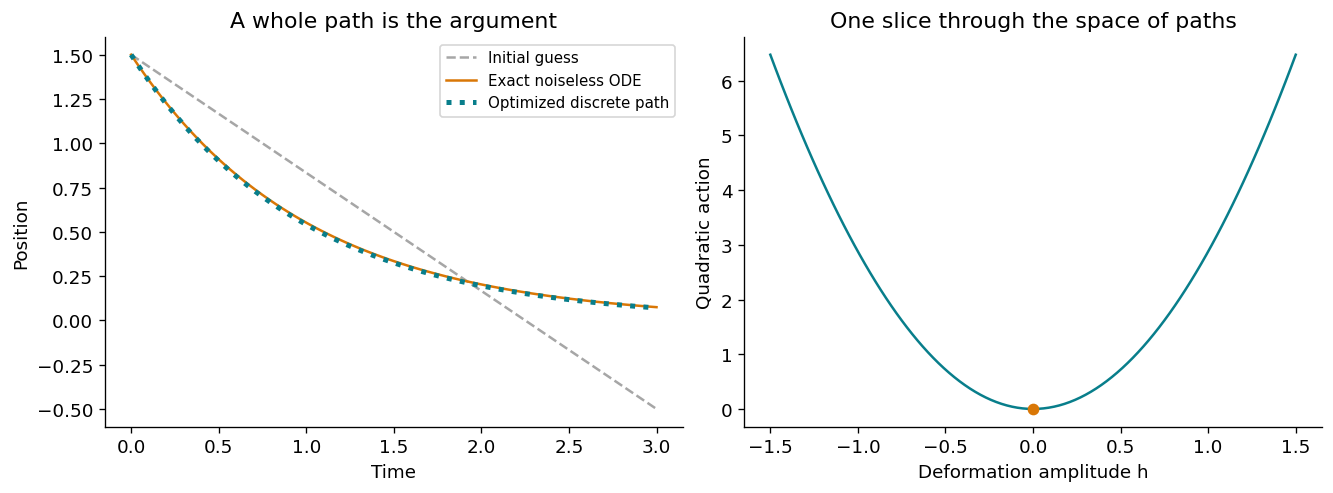

In [2]:
#| label: fig-eq4-minimum
#| fig-cap: "Minimizing the discrete action recovers the drift recursion. Moving away from it along a chosen deformation raises the action quadratically."
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(t, initial_guess, color="0.65", linestyle="--", label="Initial guess")
axes[0].plot(t, exact_ode, color="#d97706", label="Exact noiseless ODE")
axes[0].plot(t, optimized, color="#087e8b", linestyle=":", linewidth=3,
             label="Optimized discrete path")
axes[0].set(xlabel="Time", ylabel="Position", title="A whole path is the argument")
axes[0].legend(fontsize=9)
# This deformation preserves the start and leaves the endpoint free.
amplitudes = np.linspace(-1.5, 1.5, 101)
shape = t / tau
family = euler_mode[None, :] + amplitudes[:, None] * shape[None, :]
costs = discrete_action(family, lambda x: -k*x, gamma, dt)
axes[1].plot(amplitudes, costs, color="#087e8b")
axes[1].scatter([0], [0], color="#d97706", zorder=3)
axes[1].set(xlabel="Deformation amplitude h", ylabel="Quadratic action",
            title="One slice through the space of paths")
plt.show()

**Read the output:** the minimum score is essentially zero, up to numerical precision. The right panel varies just one deformation shape; the analytic nonnegativity proof establishes the minimum over all admissible paths, not only the plotted family.

### Change the question: force a different endpoint

For the linear example, the continuum minimizer with $x(\tau)=b$ is

$$x_b(t)=x_0e^{-kt}+
\frac{b-x_0e^{-k\tau}}{\sinh(k\tau)}\sinh(kt).$$

Its residual is proportional to $e^{kt}$, just as the Euler–Lagrange equation predicts. Unless $b=x_0e^{-k\tau}$, it has positive cost. The next cell solves the analogous discrete problem while keeping both ends fixed.

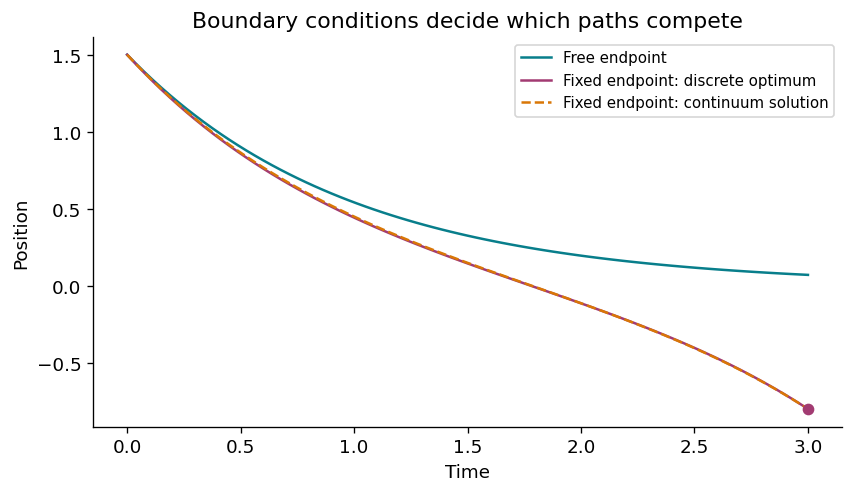

Action with imposed endpoint: 1.8630


In [3]:
#| label: fig-eq4-endpoint
#| fig-cap: "A forced endpoint changes the variational problem: the drift path is no longer admissible."
b = -0.8

def bridge_residuals(interior):
    """Scale residuals for a path whose two endpoints are fixed."""
    path = np.r_[x0, interior, b]
    return (np.diff(path) + k * path[:-1] * dt) / np.sqrt(2*gamma*dt)

bridge_result = least_squares(bridge_residuals, np.linspace(x0, b, N+1)[1:-1],
                             gtol=1e-11, ftol=1e-11, xtol=1e-11)
bridge = np.r_[x0, bridge_result.x, b]
bridge_continuum = exact_ode + (b-exact_ode[-1])*np.sinh(k*t)/np.sinh(k*tau)
# Independent analytic solution for the discrete linear bridge.
D = b - euler_mode[-1]
weights = a ** np.arange(N-1, -1, -1)
r_star = D * weights / np.dot(weights, weights)
bridge_exact_discrete = np.empty(N+1)
bridge_exact_discrete[0] = x0
for j in range(N):
    bridge_exact_discrete[j+1] = a*bridge_exact_discrete[j] + r_star[j]
assert bridge_result.success
assert np.max(np.abs(bridge - bridge_exact_discrete)) < 1e-7
assert bridge_result.cost > 0
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.plot(t, euler_mode, label="Free endpoint", color="#087e8b")
ax.plot(t, bridge, label="Fixed endpoint: discrete optimum", color="#a23b72")
ax.plot(t, bridge_continuum, "--", label="Fixed endpoint: continuum solution", color="#d97706")
ax.scatter([tau], [b], color="#a23b72", zorder=3)
ax.set(xlabel="Time", ylabel="Position", title="Boundary conditions decide which paths compete")
ax.legend(fontsize=9)
plt.show()
print(f"Action with imposed endpoint: {bridge_result.cost:.4f}")

## 11. A most likely path is not a typical noisy realization

At a fixed grid resolution, sample the Euler stochastic dynamics. For each path, the increments satisfy $r_j=\sqrt{2\gamma\Delta t}\,\xi_j$. Therefore

$$S_{\Delta t}=\frac12\sum_{j=0}^{N-1}\xi_j^2,
\qquad 2S_{\Delta t}\sim\chi_N^2.$$

The expected action is $N/2$, whereas the modal path has action zero. There is no contradiction: a high-dimensional Gaussian has its density maximum at its center, but many more configurations lie away from that center.

An exactly noiseless path has probability zero for nonzero diffusion, as does every exact path. The finite-grid modal path remains meaningful as a density maximum. In continuous time, “most likely path” requires a path measure or small-tube convention; it should not be mistaken for an event of positive probability.

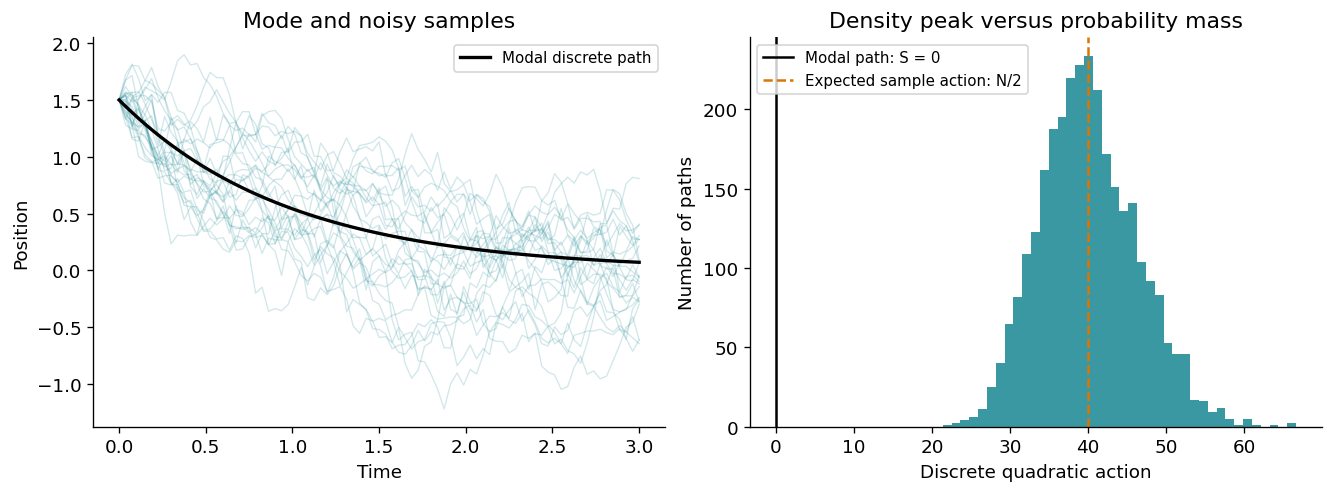

Mean sample action: 40.06; theory: 40.00


In [4]:
#| label: fig-eq4-typical
#| fig-cap: "Individual noisy paths fluctuate around the drift trajectory, while their discrete actions concentrate far above the modal path's zero action."
rng = np.random.default_rng(20260906)
M = 3000
samples = np.empty((M, N+1))
samples[:, 0] = x0
for j in range(N):
    samples[:, j+1] = a*samples[:, j] + np.sqrt(2*gamma*dt)*rng.standard_normal(M)
actions = discrete_action(samples, lambda x: -k*x, gamma, dt)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(t, samples[:25].T, color="#087e8b", alpha=0.18, linewidth=0.8)
axes[0].plot(t, euler_mode, color="black", linewidth=2, label="Modal discrete path")
axes[0].set(xlabel="Time", ylabel="Position", title="Mode and noisy samples")
axes[0].legend(fontsize=9)
axes[1].hist(actions, bins=40, color="#087e8b", alpha=0.8)
axes[1].axvline(0, color="black", label="Modal path: S = 0")
axes[1].axvline(N/2, color="#d97706", linestyle="--", label="Expected sample action: N/2")
axes[1].set(xlabel="Discrete quadratic action", ylabel="Number of paths", title="Density peak versus probability mass")
axes[1].legend(fontsize=9)
plt.show()
# The sample mean has standard error sqrt(N/(2M)).
se_action = np.sqrt(N/(2*M))
assert abs(actions.mean()-N/2) < 6*se_action
print(f"Mean sample action: {actions.mean():.2f}; theory: {N/2:.2f}")

**Why specify a grid?** Increasing $N$ raises the expected sample action $N/2$. Typical Brownian paths do not have finite classical squared-velocity action in the continuum limit. Smooth-path action minimization and sampling rough diffusion trajectories are related constructions, but they are not interchangeable pointwise calculations.

## 12. The drift path is not generally the ensemble mean

For additive noise with zero mean,

$$\frac{d}{dt}\mathbb E[x_t]=\mathbb E[f(x_t)].$$

If $f(x)=-kx$, linearity gives $\mathbb E[f(x)]=f(\mathbb E[x])$. The mean follows the noiseless ODE. For nonlinear $f$, that equality generally fails.

Use a double-well drift $f(x)=x-x^3$. A deterministic trajectory starting at $x_0=0.5$ approaches $+1$. Noise can carry some realizations into the left well, and the ensemble mean can move away from the deterministic curve. Here we compare the mean with the **noiseless reference**, not assert that the latter is the exact finite-noise Onsager–Machlup mode: this nonlinear flow has a nonconstant divergence.

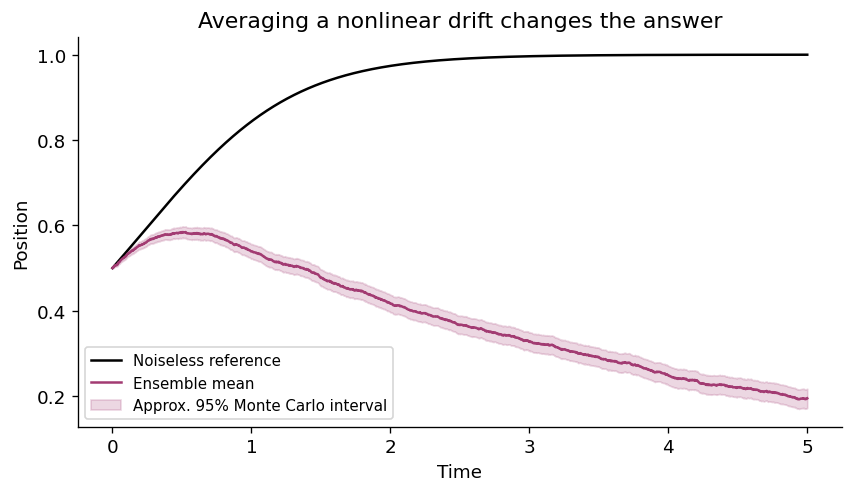

Terminal mean: 0.195 ± 0.023 (Monte Carlo only)
Terminal noiseless position: 1.000


In [5]:
#| label: fig-eq4-nonlinear
#| fig-cap: "For a nonlinear double-well drift, the ensemble mean differs from the noiseless trajectory. The shaded band shows Monte Carlo uncertainty in the mean, not the spread of individual paths."
rng_nl = np.random.default_rng(314159)
T_nl, dt_nl, gamma_nl, M_nl = 5.0, 0.002, 0.30, 6000
steps_nl = round(T_nl/dt_nl)
time_nl = np.linspace(0, T_nl, steps_nl+1)
state = np.full(M_nl, 0.5)
mean_nl = np.empty(steps_nl+1)
se_nl = np.empty_like(mean_nl)
drift_path = np.empty_like(mean_nl)
mean_nl[0], se_nl[0], drift_path[0] = 0.5, 0.0, 0.5
for j in range(steps_nl):
    state += (state-state**3)*dt_nl + np.sqrt(2*gamma_nl*dt_nl)*rng_nl.standard_normal(M_nl)
    mean_nl[j+1] = state.mean()
    se_nl[j+1] = state.std(ddof=1)/np.sqrt(M_nl)
    y = drift_path[j]
    drift_path[j+1] = y + (y-y**3)*dt_nl
assert np.isfinite(state).all()
assert abs(mean_nl[-1]-drift_path[-1]) > 6*se_nl[-1]
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.plot(time_nl, drift_path, color="black", label="Noiseless reference")
ax.plot(time_nl, mean_nl, color="#a23b72", label="Ensemble mean")
ax.fill_between(time_nl, mean_nl-1.96*se_nl, mean_nl+1.96*se_nl,
                color="#a23b72", alpha=0.2, label="Approx. 95% Monte Carlo interval")
ax.set(xlabel="Time", ylabel="Position", title="Averaging a nonlinear drift changes the answer")
ax.legend(fontsize=9)
plt.show()
print(f"Terminal mean: {mean_nl[-1]:.3f} ± {1.96*se_nl[-1]:.3f} (Monte Carlo only)")
print(f"Terminal noiseless position: {drift_path[-1]:.3f}")

## 13. Return to the divergence term

The divergence

$$\nabla\cdot f=\sum_i\frac{\partial f_i}{\partial x_i}$$

measures local expansion or contraction of a small cloud of deterministic states. The paper includes $\tfrac12\nabla\cdot f$ in its full Lagrangian and explicitly omits its contribution in the explanation of Equation (4).

For constant divergence, the extra integral is the same for every path of a fixed duration. Our linear example has divergence $-k$, so the minimizer is unaffected.

For nonconstant divergence, its variation contributes an additional term:

$$\dot\varepsilon=-\Gamma J^{\mathsf T}\Gamma^{-1}\varepsilon
+\Gamma\nabla(\nabla\cdot f).$$

The natural boundary condition still gives $\varepsilon(\tau)=0$, but this equation is now forced. The zero residual need not solve it. This is why the unqualified claim “the most likely path always follows the drift” would be too strong.

The paper motivates neglecting this contribution by locally approximating the drift as linear over a suitable short interval, or by considering small noise. If $\Gamma=\epsilon D$ with fixed $D$, the quadratic term scales as $1/\epsilon$ while the divergence term is order one. This identifies a leading-order small-noise action; it does not establish a uniform correction estimate for every nonlinear problem.

## 14. Sanity checks and exercises

1. **No drift:** set $f=0$, keep the endpoint free. What path minimizes $S$?
2. **An imposed endpoint:** for $f=0$ and $x(\tau)=b$, find the minimizing path and its action in one dimension.
3. **More noise:** replace scalar $\gamma$ by $2\gamma$ while keeping candidate paths fixed. What changes about their quadratic costs and density ratios?
4. **A special endpoint:** in the linear bridge example, choose $b=x_0(1-k\Delta t)^N$. What should happen to the discrete minimum?
5. **First variation:** why can we not discard the terminal boundary term in the free-endpoint problem?
6. **Convexity:** why does a quadratic cost in $\varepsilon$ not prove convexity in $x$?

### Worked answers

1. The constant path $x(t)=x_0$ has zero residual and zero cost. Brownian samples nevertheless fluctuate.
2. The straight line $x(t)=x_0+(b-x_0)t/\tau$ minimizes the integral of squared velocity. Its cost is $(b-x_0)^2/(4\gamma\tau)$. One proof is Cauchy–Schwarz: $(\int\dot x\,dt)^2\leq\tau\int\dot x^2dt$.
3. Every fixed-path quadratic cost halves. On the same grid, ratios become $\exp[-\Delta S/2]$ instead of $\exp[-\Delta S]$: likelihood differences become less pronounced. The common normalizer changes too, but cancels in ratios.
4. The imposed endpoint is now compatible with the Euler drift path, so the minimum returns to zero.
5. $\eta(\tau)$ is arbitrary, not zero. Its coefficient must vanish, giving the natural boundary condition. Forgetting it admits extraneous solutions of the interior Euler–Lagrange equation.
6. A nonlinear $f(x)$ makes the map $x\mapsto\varepsilon$ nonlinear. The composition need not be convex. The zero-cost proof remains valid because it attains a global lower bound.

As $\Gamma\to0$ with a fixed admissible nonzero residual, the quadratic cost diverges. Under suitable regularity over finite times, the stochastic trajectories concentrate around the noiseless solution. This is a limiting statement about the stochastic dynamics; the absolute normalized action also contains grid-dependent constants.

## 15. Read Equation (4) once more

| Line | Read it in words | What makes it work here? |
|---|---|---|
| $\mathbf x[\tau]=\arg\min\mathcal A$ | Select a whole path with largest density | Negative logarithms reverse likelihood ordering |
| $\delta_x\mathcal A=0$ | No admissible infinitesimal deformation changes its action at first order | Interior Euler–Lagrange equation **and** free-terminal boundary condition |
| $\dot{\mathbf x}=f(\mathbf x)$ | The selected path follows the drift | Nonnegative quadratic cost can reach zero; divergence contribution omitted |

The action scores a whole path; it is not the state surprisal at the endpoint. Minimizing it does not say that state surprisal decreases monotonically at every moment, and it does not require an organism consciously to predict anything.

This supplies a useful foundation for later variational arguments in the FEP. Later equations introduce different states and objectives; their assumptions still need checking individually.

## Sources and using this notebook in a Quarto book

**Primary source:** Karl Friston, Lancelot Da Costa, Noor Sajid, Conor Heins, Kai Ueltzhöffer, Grigorios A. Pavliotis, and Thomas Parr (2023). *The free energy principle made simpler but not too simple*. Physics Reports, 1024, 1–29. [DOI: 10.1016/j.physrep.2023.07.001](https://doi.org/10.1016/j.physrep.2023.07.001). See Section 2, Equations (1)–(5), especially footnotes 3–4. This notebook develops the supplied teaching drafts while correcting the white-noise scaling and convexity claims. The finite-grid derivations, endpoint analysis, and numerical demonstrations are worked out here.

**Quarto workflow:** [Quarto's JupyterLab guide](https://quarto.org/docs/tools/jupyter-lab.html) specifies a raw YAML cell for document options, Markdown cells for narrative, and `#|` comments for code-cell options. This notebook follows that structure. It has no external data or image dependencies.

Place `equation-4-least-action.ipynb` beside your other chapters and append it to your existing `book.chapters` list in `_quarto.yml`, preserving the other entries:

```yaml
book:
  chapters:
    - index.qmd
    # Keep your other chapter entries here.
    - equation-4-least-action.ipynb
```

The `index.qmd` line is illustrative: keep your actual existing index and configuration. See [Quarto book structure](https://quarto.org/docs/books/book-structure.html).

Install the runtime packages if needed:

```bash
python -m pip install jupyterlab numpy scipy matplotlib
```

Run all cells in JupyterLab and save. Quarto normally uses the saved notebook outputs. From a terminal in your book directory:

```bash
quarto preview
```

To render and recompute this notebook explicitly:

```bash
quarto render equation-4-least-action.ipynb --execute
```

The notebook uses seeded simulations for reproducibility. Monte Carlo intervals in the nonlinear example quantify sampling uncertainty only; they do not bound Euler time-discretization error.